In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# 1. Load data
train = pd.read_csv("crime_train.csv")
test = pd.read_csv("crime_test.csv")

In [3]:
# 2. Clean data
for df in (train, test):
    df["weapon"] = df["weapon"].fillna("None")            # no weapon recorded = its own category
    date = pd.to_datetime(df["case_filed"], format="%m-%d-%Y %H:%M")
    df["hour"] = date.dt.hour
    df["month"] = date.dt.month
    df["year"] = date.dt.year
    df["weekday"] = date.dt.dayofweek
    df["target"] = (df["closed"] == "Yes").astype(int)    # Yes -> 1, No -> 0

number_cols = ["area", "age", "police_department", "hour", "month", "year", "weekday"]
text_cols = ["city", "crime_description", "sex", "weapon", "domain"]

In [4]:
# 3. Turn text columns into 0/1 columns (one-hot), same columns for train and test
both = pd.concat([train, test])
X_all = pd.concat([both[number_cols].astype(float),
                   pd.get_dummies(both[text_cols], dtype=float)], axis=1).values
X_train = X_all[:len(train)]
X_test = X_all[len(train):]
y_train = train["target"].values
y_test = test["target"].values

In [5]:
# 4. Scale using train statistics only
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)
std[std == 0] = 1
X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

In [6]:
# 5. Add bias column
X_train = np.c_[np.ones(len(X_train)), X_train]
X_test = np.c_[np.ones(len(X_test)), X_test]


In [7]:
# 6. Helper functions
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def accuracy(X, y, w):
    predictions = (sigmoid(X @ w) >= 0.5).astype(int)
    return np.mean(predictions == y) * 100

In [8]:
# 7. Gradient descent
w = np.zeros(X_train.shape[1])
lr = 0.1
epochs = 1000
losses = []

for i in range(epochs):
    p = sigmoid(X_train @ w)
    loss = -np.mean(y_train * np.log(p + 1e-12) + (1 - y_train) * np.log(1 - p + 1e-12))
    losses.append(loss)

    w = w - lr * (X_train.T @ (p - y_train)) / len(y_train)

    train_acc = accuracy(X_train, y_train, w)
    test_acc = accuracy(X_test, y_test, w)
    print("Epoch", i + 1, "| Loss:", round(loss, 4),
          "| Train acc:", round(train_acc, 2), "| Test acc:", round(test_acc, 2))

Epoch 1 | Loss: 0.6931 | Train acc: 51.71 | Test acc: 49.54
Epoch 2 | Loss: 0.6931 | Train acc: 51.69 | Test acc: 49.4
Epoch 3 | Loss: 0.693 | Train acc: 51.75 | Test acc: 49.31
Epoch 4 | Loss: 0.693 | Train acc: 51.67 | Test acc: 49.27
Epoch 5 | Loss: 0.693 | Train acc: 51.6 | Test acc: 49.31
Epoch 6 | Loss: 0.6929 | Train acc: 51.54 | Test acc: 49.29
Epoch 7 | Loss: 0.6929 | Train acc: 51.53 | Test acc: 49.31
Epoch 8 | Loss: 0.6928 | Train acc: 51.54 | Test acc: 49.27
Epoch 9 | Loss: 0.6928 | Train acc: 51.56 | Test acc: 49.26
Epoch 10 | Loss: 0.6928 | Train acc: 51.59 | Test acc: 49.29
Epoch 11 | Loss: 0.6927 | Train acc: 51.59 | Test acc: 49.35
Epoch 12 | Loss: 0.6927 | Train acc: 51.57 | Test acc: 49.37
Epoch 13 | Loss: 0.6927 | Train acc: 51.55 | Test acc: 49.36
Epoch 14 | Loss: 0.6927 | Train acc: 51.53 | Test acc: 49.36
Epoch 15 | Loss: 0.6926 | Train acc: 51.48 | Test acc: 49.42
Epoch 16 | Loss: 0.6926 | Train acc: 51.5 | Test acc: 49.37
Epoch 17 | Loss: 0.6926 | Train acc: 51

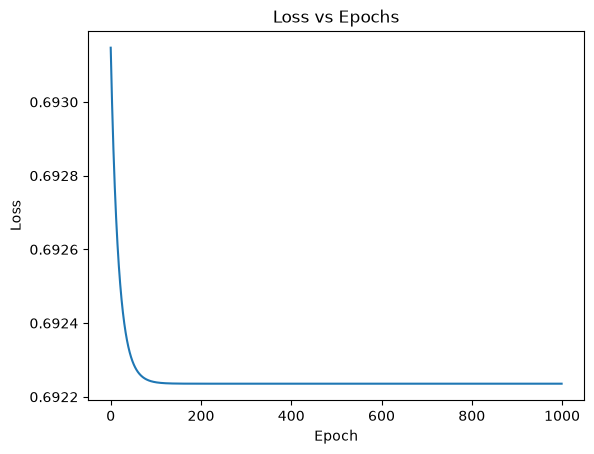

In [9]:
# 8. Plot loss
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epochs")
plt.show()